# ```Are Prices Justified? - IPL 2026```

## 1.Data Import

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings('ignore')

In [2]:
batters = pd.read_csv(r"C:\Users\Rano's PC\Machine\InsightForge\InsightForge\Are Prices Justified - IPL 2026\_dataset\_cleaned_data\batters.csv")
bowlers = pd.read_csv(r"C:\Users\Rano's PC\Machine\InsightForge\InsightForge\Are Prices Justified - IPL 2026\_dataset\_cleaned_data\bowlers.csv")

In [3]:
batters.head()

,pos,player,runs,mat,inns,no,sr,boundary_pct,avg_balls_inns,base_price,final_price,role,final_price_rate,cricket_role
0,71,Abdul Samad,116,8,8,2,131.81,60.34,11.00,3000000,42000000,Uncapped,14.0,Batters
1,8,Abhishek Sharma,563,15,15,1,204.72,81.35,18.33,2000000,65000000,Capped,32.5,All Rounders
2,156,Adam Milne,2,1,1,1,100.00,0.00,2.00,20000000,24000000,Capped,1.2,Bowlers
3,46,Aiden Markram,231,12,11,2,138.32,63.20,15.18,20000000,20000000,Capped,1.0,All Rounders
4,27,Ajinkya Rahane,335,14,14,1,135.08,62.09,17.71,15000000,15000000,Capped,1.0,Batters


In [4]:
bowlers.head()

,pos,player,wkts,mat,inns,ov,runs,avg,econ,sr,base_price,final_price,role,final_price_rate,cricket_role
0,75,Abhinandan Singh,3,3,3,9.4,122,40.66,12.62,19.33,3000000,3000000,Uncapped,1.00,Bowlers
1,72,Akash Singh,4,2,2,7.0,80,20.00,11.42,10.50,3000000,3000000,Uncapped,1.00,Bowlers
2,44,Akeal Hosein,8,7,7,24.4,198,24.75,8.02,18.50,20000000,20000000,Capped,1.00,All Rounders
3,5,Anshul Kamboj,21,14,14,50.2,530,25.23,10.52,14.38,3000000,34000000,Uncapped,11.33,Bowlers
4,39,Anukul Roy,9,14,12,27.1,261,29.00,9.60,18.11,3000000,4000000,Uncapped,1.33,All Rounders


## 2.Filtering

In [5]:
batters = batters[batters['inns']>5]
bowlers = bowlers[bowlers['inns']>5]

In [6]:
only_batters = batters[batters['cricket_role']!='Bowlers']
only_bowlers = bowlers[bowlers['cricket_role']!='Batters']

In [7]:
only_batters.head()

,pos,player,runs,mat,inns,no,sr,boundary_pct,avg_balls_inns,base_price,final_price,role,final_price_rate,cricket_role
0,71,Abdul Samad,116,8,8,2,131.81,60.34,11.00,3000000,42000000,Uncapped,14.0,Batters
1,8,Abhishek Sharma,563,15,15,1,204.72,81.35,18.33,2000000,65000000,Capped,32.5,All Rounders
3,46,Aiden Markram,231,12,11,2,138.32,63.20,15.18,20000000,20000000,Capped,1.0,All Rounders
4,27,Ajinkya Rahane,335,14,14,1,135.08,62.09,17.71,15000000,15000000,Capped,1.0,Batters
7,20,Angkrish Raghuvanshi,422,13,12,2,146.52,64.93,24.00,3000000,30000000,Uncapped,10.0,Batters


In [8]:
only_bowlers.head()

,pos,player,wkts,mat,inns,ov,runs,avg,econ,sr,base_price,final_price,role,final_price_rate,cricket_role
2,44,Akeal Hosein,8,7,7,24.4,198,24.75,8.02,18.50,20000000,20000000,Capped,1.00,All Rounders
3,5,Anshul Kamboj,21,14,14,50.2,530,25.23,10.52,14.38,3000000,34000000,Uncapped,11.33,Bowlers
4,39,Anukul Roy,9,14,12,27.1,261,29.00,9.60,18.11,3000000,4000000,Uncapped,1.33,All Rounders
6,21,Arshdeep Singh,14,14,14,53.0,541,38.64,10.20,22.71,20000000,180000000,Capped,9.00,Bowlers
7,55,Ashok Sharma,6,6,6,21.0,228,38.00,10.85,21.00,3000000,9000000,Uncapped,3.00,Bowlers


## 3.Data Analysis

### 3.1 Univariate Analysis

**BATTERS**

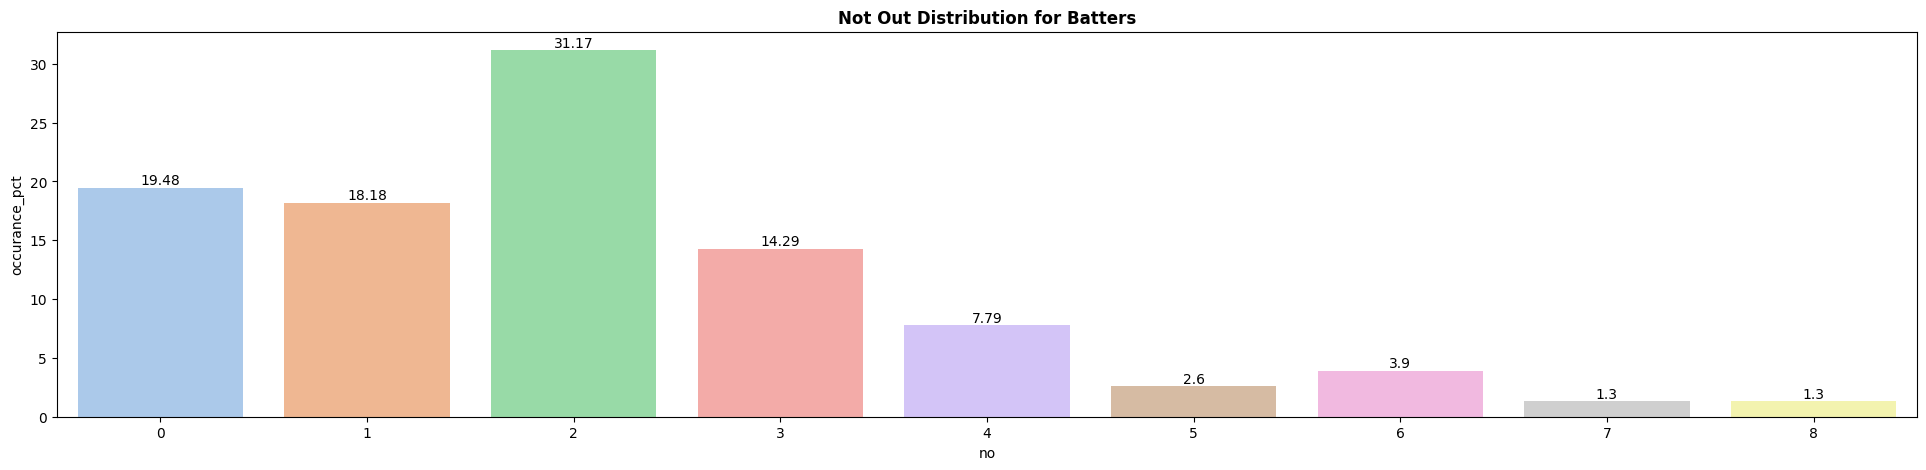

In [9]:
no_dist = only_batters['no'].value_counts(normalize=True).mul(100).reset_index(name='occurance_pct').round(2)

plt.figure(figsize=(24,5))
ax = sns.barplot(y='occurance_pct',x='no',data=no_dist,palette='pastel')
for container in ax.containers:
    ax.bar_label(container=container)
plt.title("Not Out Distribution for Batters",weight='bold')
plt.show()

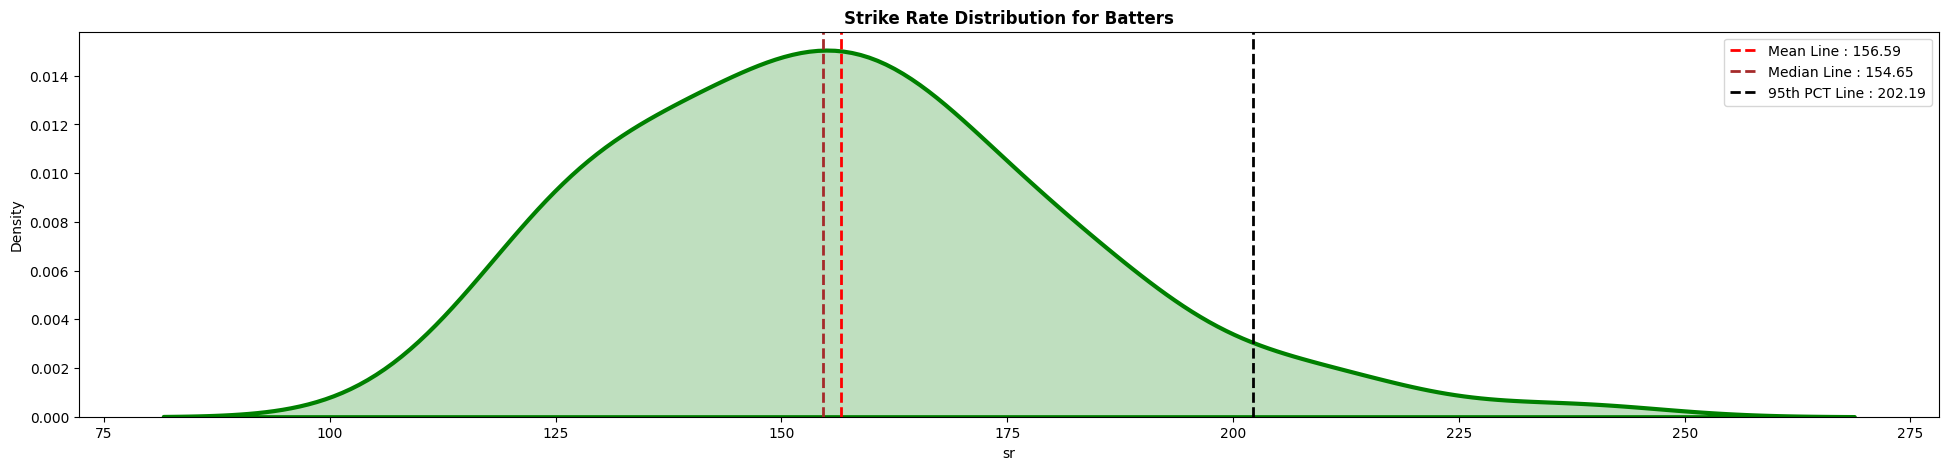

In [10]:
plt.figure(figsize=(24,5))
sns.kdeplot(x='sr',
            data=only_batters,
            linewidth=3,
            fill=True,
            color='green',
            )
plt.axvline(only_batters['sr'].mean(),color='red',linestyle='--',linewidth=2,label=f"Mean Line : {only_batters['sr'].mean().round(2)}")
plt.axvline(only_batters['sr'].median(),color='brown',linestyle='--',linewidth=2,label=f"Median Line : {round(only_batters['sr'].median(),2)}")
plt.axvline(only_batters['sr'].quantile(.95),color='black',linestyle='--',linewidth=2,label=f"95th PCT Line : {only_batters['sr'].quantile(.95).round(2)}")

plt.title("Strike Rate Distribution for Batters",weight='bold')
plt.grid(False)
plt.legend()
plt.show()

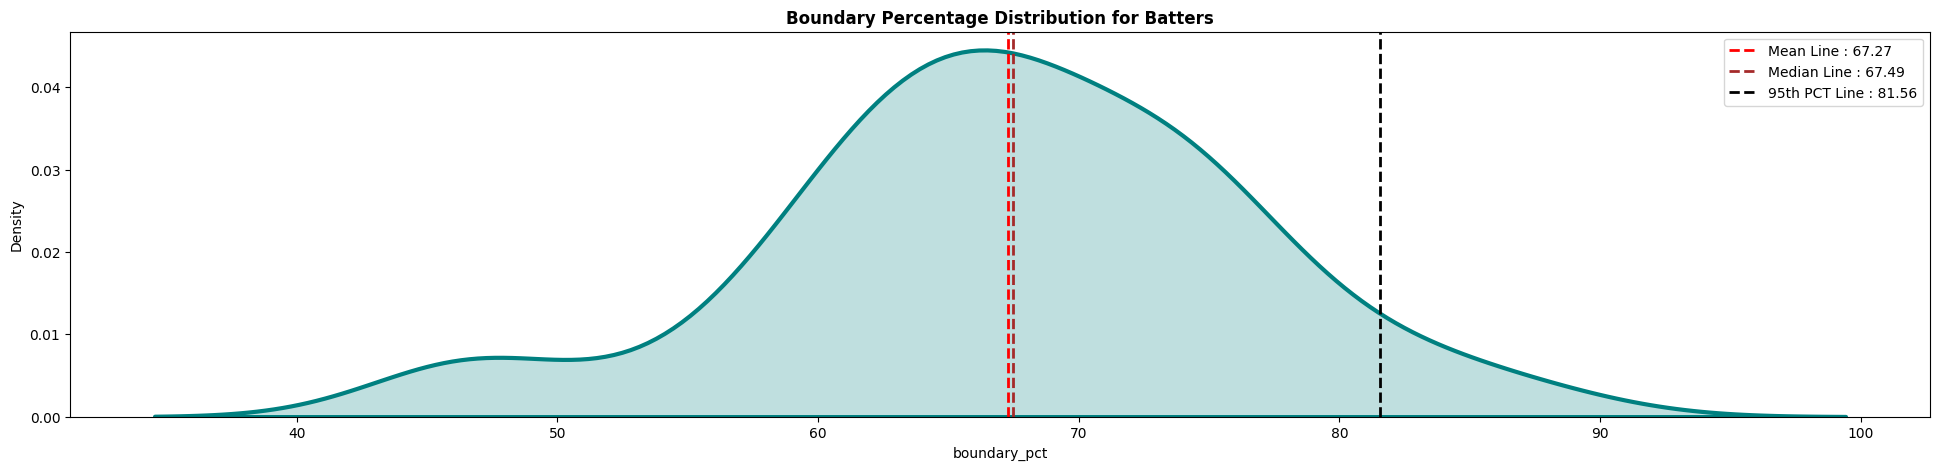

In [11]:
plt.figure(figsize=(24,5))
sns.kdeplot(x='boundary_pct',
            data=only_batters,
            linewidth=3,
            fill=True,
            color='teal',
            )
plt.axvline(only_batters['boundary_pct'].mean(),color='red',linestyle='--',linewidth=2,label=f"Mean Line : {only_batters['boundary_pct'].mean().round(2)}")
plt.axvline(only_batters['boundary_pct'].median(),color='brown',linestyle='--',linewidth=2,label=f"Median Line : {round(only_batters['boundary_pct'].median(),2)}")
plt.axvline(only_batters['boundary_pct'].quantile(.95),color='black',linestyle='--',linewidth=2,label=f"95th PCT Line : {only_batters['boundary_pct'].quantile(.95).round(2)}")

plt.title("Boundary Percentage Distribution for Batters",weight='bold')
plt.grid(False)
plt.legend()
plt.show()

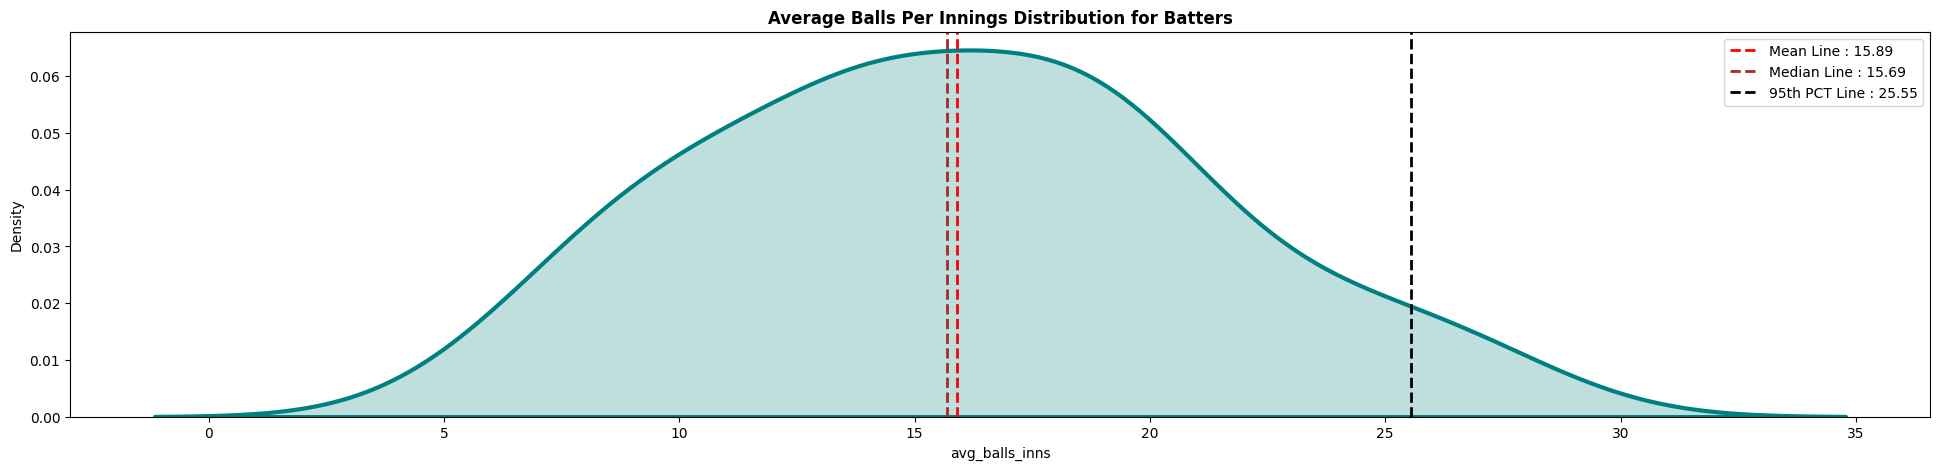

In [12]:
plt.figure(figsize=(24,5))
sns.kdeplot(x='avg_balls_inns',
            data=only_batters,
            linewidth=3,
            fill=True,
            color='teal',
            )
plt.axvline(only_batters['avg_balls_inns'].mean(),color='red',linestyle='--',linewidth=2,label=f"Mean Line : {only_batters['avg_balls_inns'].mean().round(2)}")
plt.axvline(only_batters['avg_balls_inns'].median(),color='brown',linestyle='--',linewidth=2,label=f"Median Line : {round(only_batters['avg_balls_inns'].median(),2)}")
plt.axvline(only_batters['avg_balls_inns'].quantile(.95),color='black',linestyle='--',linewidth=2,label=f"95th PCT Line : {only_batters['avg_balls_inns'].quantile(.95).round(2)}")

plt.title("Average Balls Per Innings Distribution for Batters",weight='bold')
plt.grid(False)
plt.legend()
plt.show()

**BOWLERS**

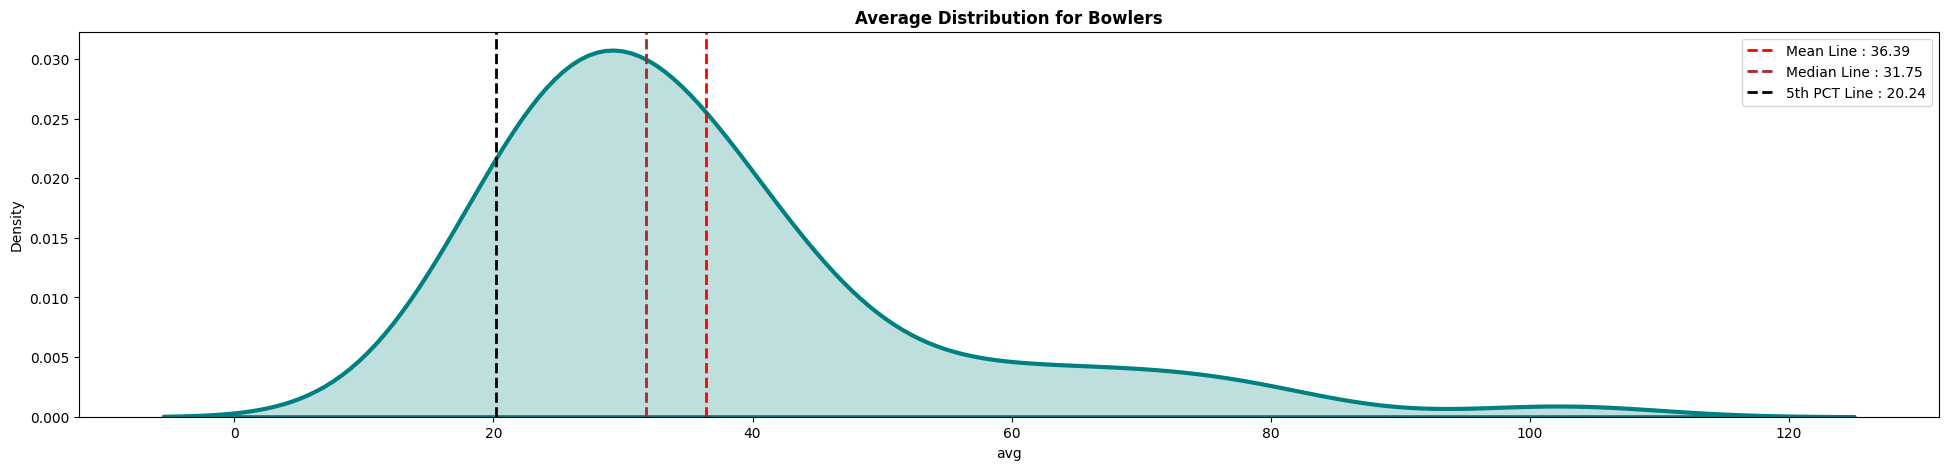

In [13]:
plt.figure(figsize=(24,5))
sns.kdeplot(x='avg',
            data=only_bowlers,
            linewidth=3,
            fill=True,
            color='teal',
            )
plt.axvline(only_bowlers['avg'].mean(),color='red',linestyle='--',linewidth=2,label=f"Mean Line : {only_bowlers['avg'].mean().round(2)}")
plt.axvline(only_bowlers['avg'].median(),color='brown',linestyle='--',linewidth=2,label=f"Median Line : {round(only_bowlers['avg'].median(),2)}")
plt.axvline(only_bowlers['avg'].quantile(.05),color='black',linestyle='--',linewidth=2,label=f"5th PCT Line : {only_bowlers['avg'].quantile(.05).round(2)}")

plt.title("Average Distribution for Bowlers",weight='bold')
plt.grid(False)
plt.legend()
plt.show()

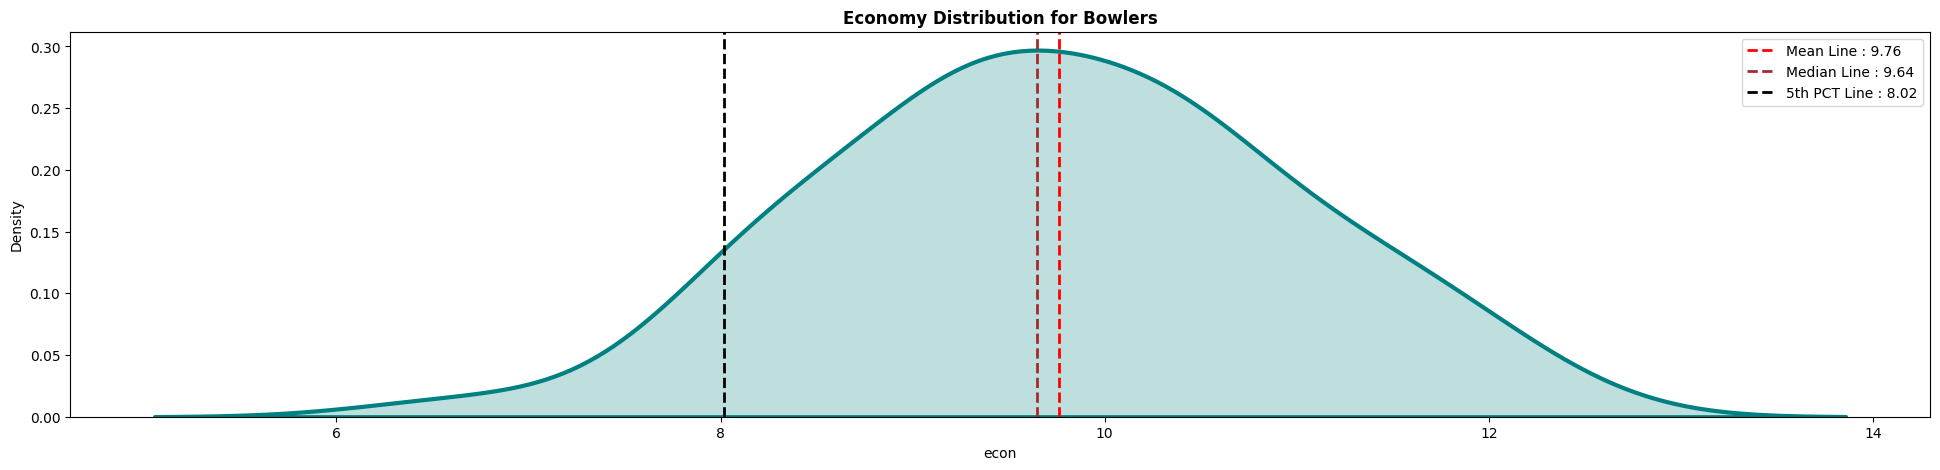

In [14]:
plt.figure(figsize=(24,5))
sns.kdeplot(x='econ',
            data=only_bowlers,
            linewidth=3,
            fill=True,
            color='teal',
            )
plt.axvline(only_bowlers['econ'].mean(),color='red',linestyle='--',linewidth=2,label=f"Mean Line : {only_bowlers['econ'].mean().round(2)}")
plt.axvline(only_bowlers['econ'].median(),color='brown',linestyle='--',linewidth=2,label=f"Median Line : {round(only_bowlers['econ'].median(),2)}")
plt.axvline(only_bowlers['econ'].quantile(.05),color='black',linestyle='--',linewidth=2,label=f"5th PCT Line : {only_bowlers['econ'].quantile(.05).round(2)}")

plt.title("Economy Distribution for Bowlers",weight='bold')
plt.grid(False)
plt.legend()
plt.show()

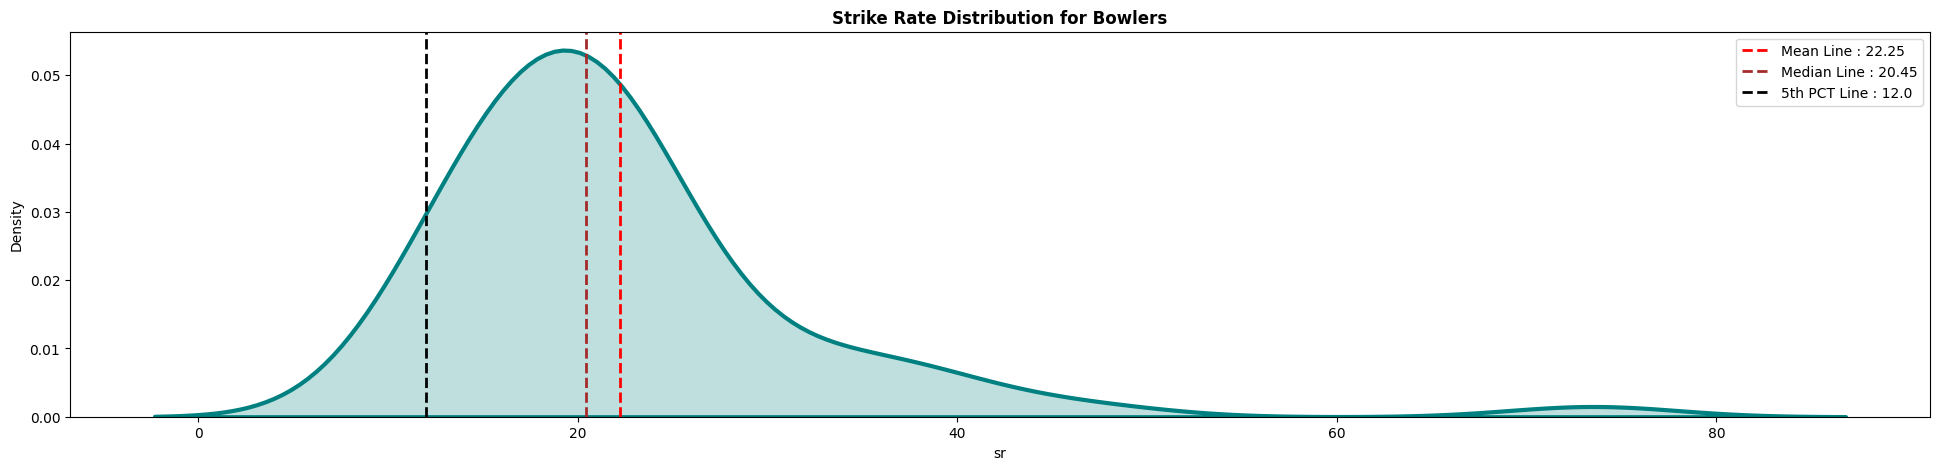

In [15]:
plt.figure(figsize=(24,5))
sns.kdeplot(x='sr',
            data=only_bowlers,
            linewidth=3,
            fill=True,
            color='teal',
            )
plt.axvline(only_bowlers['sr'].mean(),color='red',linestyle='--',linewidth=2,label=f"Mean Line : {only_bowlers['sr'].mean().round(2)}")
plt.axvline(only_bowlers['sr'].median(),color='brown',linestyle='--',linewidth=2,label=f"Median Line : {round(only_bowlers['sr'].median(),2)}")
plt.axvline(only_bowlers['sr'].quantile(.05),color='black',linestyle='--',linewidth=2,label=f"5th PCT Line : {only_bowlers['sr'].quantile(.05).round(2)}")

plt.title("Strike Rate Distribution for Bowlers",weight='bold')
plt.grid(False)
plt.legend()
plt.show()

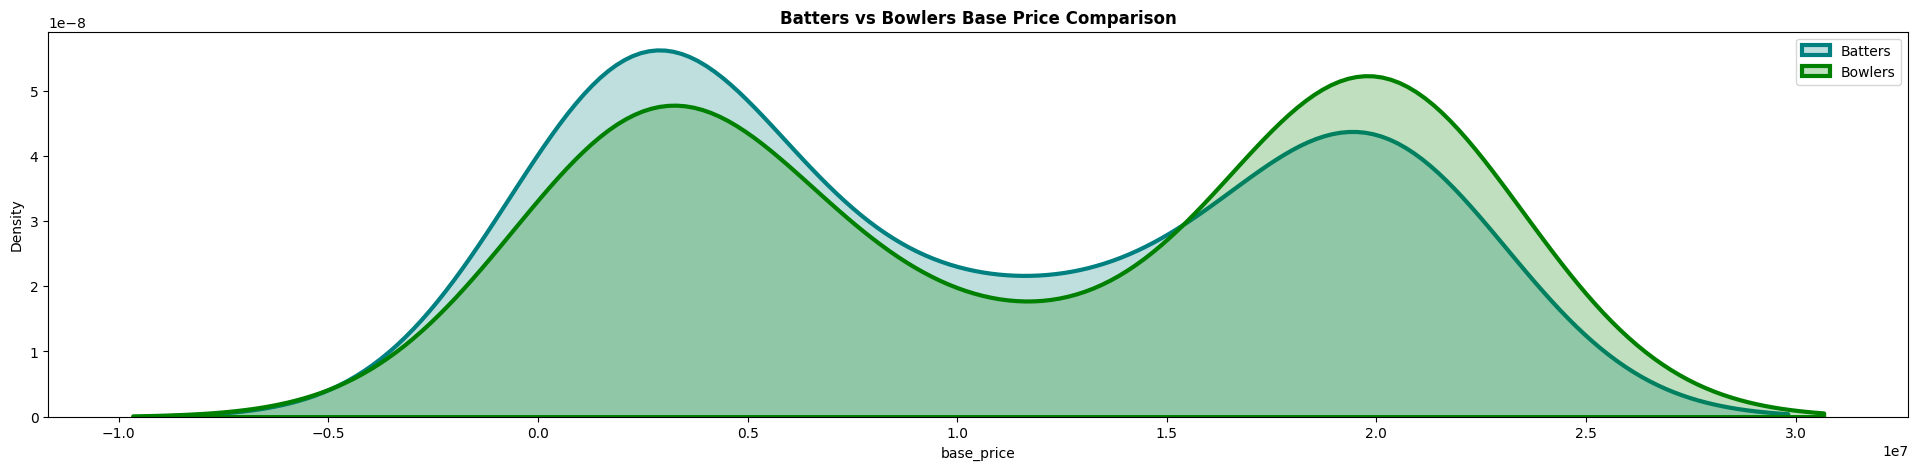

In [16]:
plt.figure(figsize=(24,5))
sns.kdeplot(x='base_price',
            data=only_batters,
            linewidth=3,
            fill=True,
            color='teal',
            label='Batters')
sns.kdeplot(x='base_price',
            data=only_bowlers,
            linewidth=3,
            fill=True,
            color='green',
            label='Bowlers')
plt.title("Batters vs Bowlers Base Price Comparison",weight='bold')
plt.legend()
plt.show()

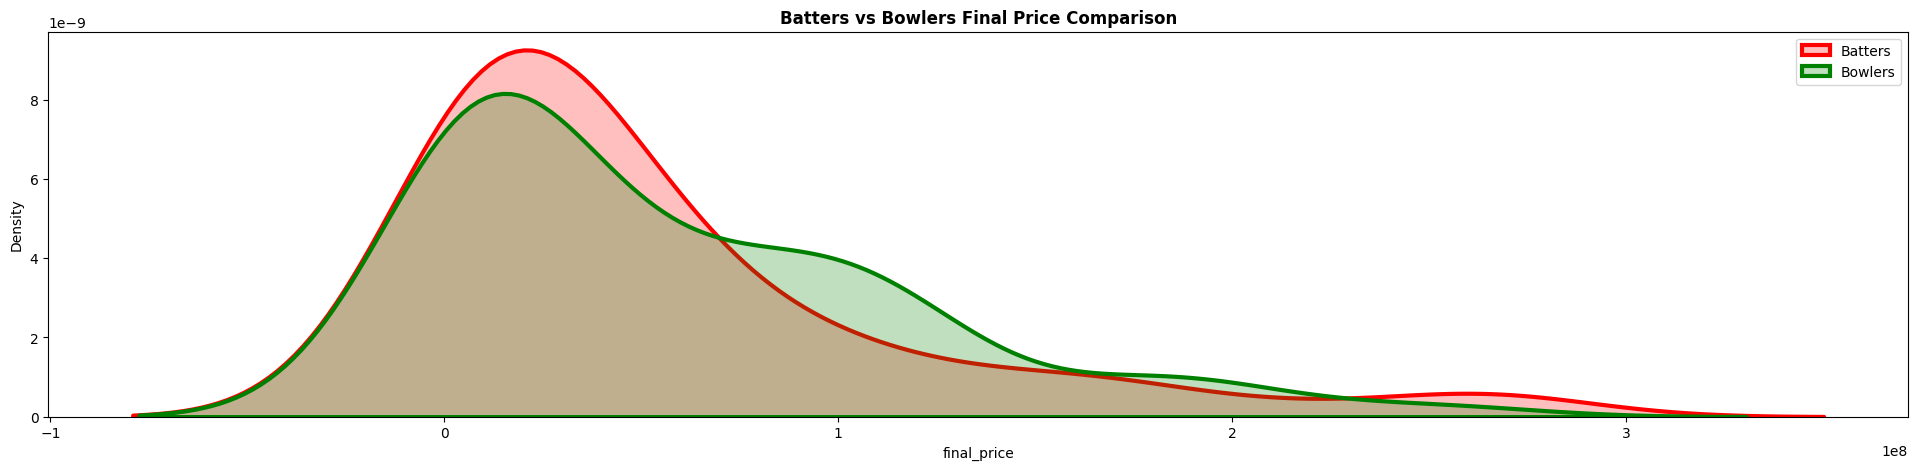

In [17]:
plt.figure(figsize=(24,5))
sns.kdeplot(x='final_price',
            data=only_batters,
            linewidth=3,
            fill=True,
            color='red',
            label='Batters')
sns.kdeplot(x='final_price',
            data=only_bowlers,
            linewidth=3,
            fill=True,
            color='green',
            label='Bowlers')
plt.title("Batters vs Bowlers Final Price Comparison",weight='bold')
plt.legend()
plt.show()

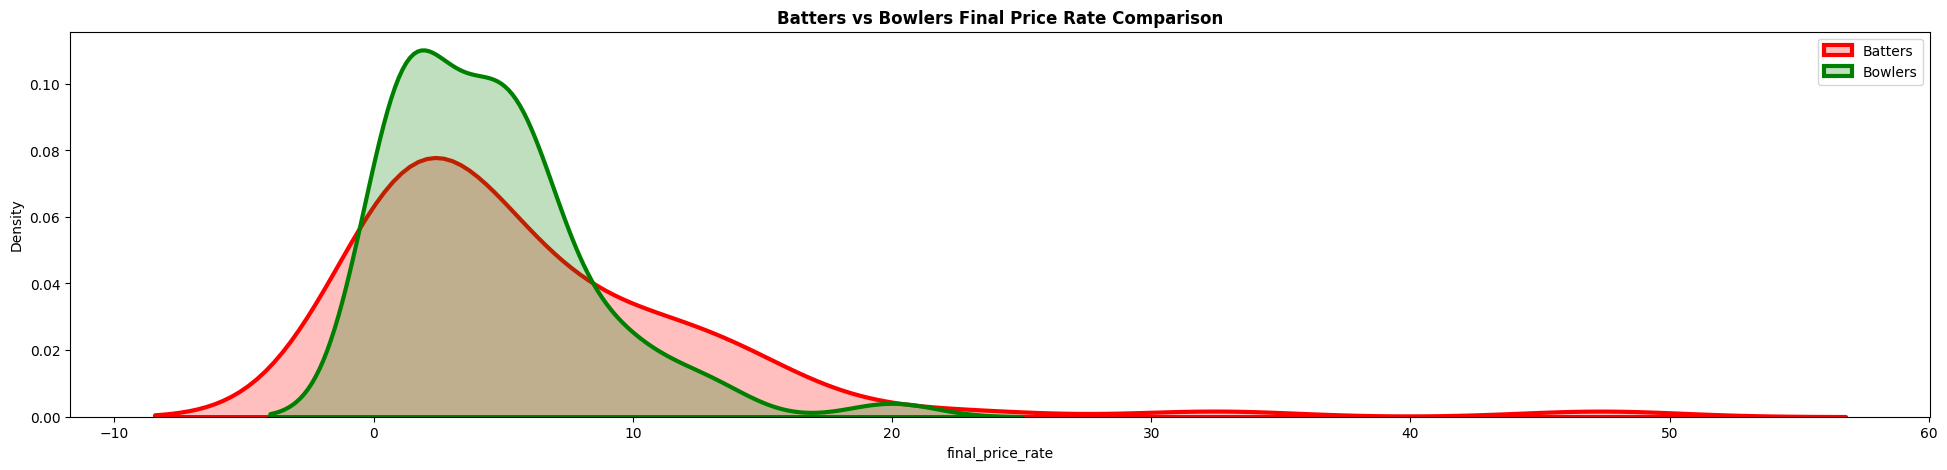

In [18]:
plt.figure(figsize=(24,5))
sns.kdeplot(x='final_price_rate',
            data=only_batters,
            linewidth=3,
            fill=True,
            color='red',
            label='Batters')
sns.kdeplot(x='final_price_rate',
            data=only_bowlers,
            linewidth=3,
            fill=True,
            color='green',
            label='Bowlers')
plt.title("Batters vs Bowlers Final Price Rate Comparison",weight='bold')
plt.legend()
plt.show()

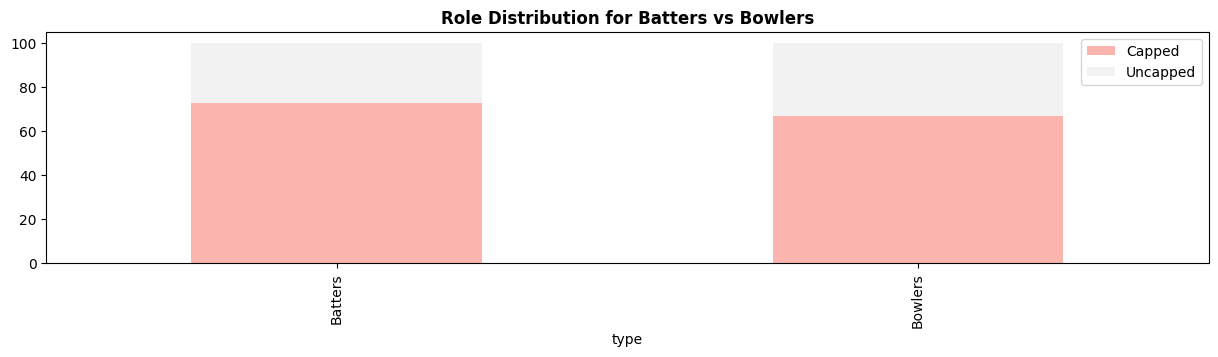

In [19]:
batters_role_dist = only_batters['role'].value_counts(normalize=True).mul(100).round(2).reset_index(name='occurance_pct')
bowlers_role_dist = only_bowlers['role'].value_counts(normalize=True).mul(100).round(2).reset_index(name='occurance_pct')
combined = pd.concat([batters_role_dist, bowlers_role_dist])
combined['type'] = ['Batters']*len(batters_role_dist) + ['Bowlers']*len(bowlers_role_dist)
pivot = combined.pivot(index='type', columns='role', values='occurance_pct').fillna(0)

pivot.plot(kind='bar', stacked=True, colormap='Pastel1', figsize=(15,3))
plt.title("Role Distribution for Batters vs Bowlers", weight='bold')
plt.legend()
plt.show()

---
---
***Key Findings:***

```Not out more than 4 times, is a good statistics```

```Strike Rate 200 or more keeps a batter in top 5 percentile```

```80% or more boundary percentage keeps a batter in top 5 percentile```

```On average 24 balls per innings keep a batter in top 5```

```Average of 20 or less keeps a bowler in top 5 percentile```

```Economy less than 8 keeps a bowler in top 5 percentile```

```Bowling Strike Rate less than 12 keeps a bowler in top 5 percentile```

```Price Rate goes higher in terms of batters, compared to bowlers```

---
---

### 3.2 Bivariate Analysis

**BATTER**

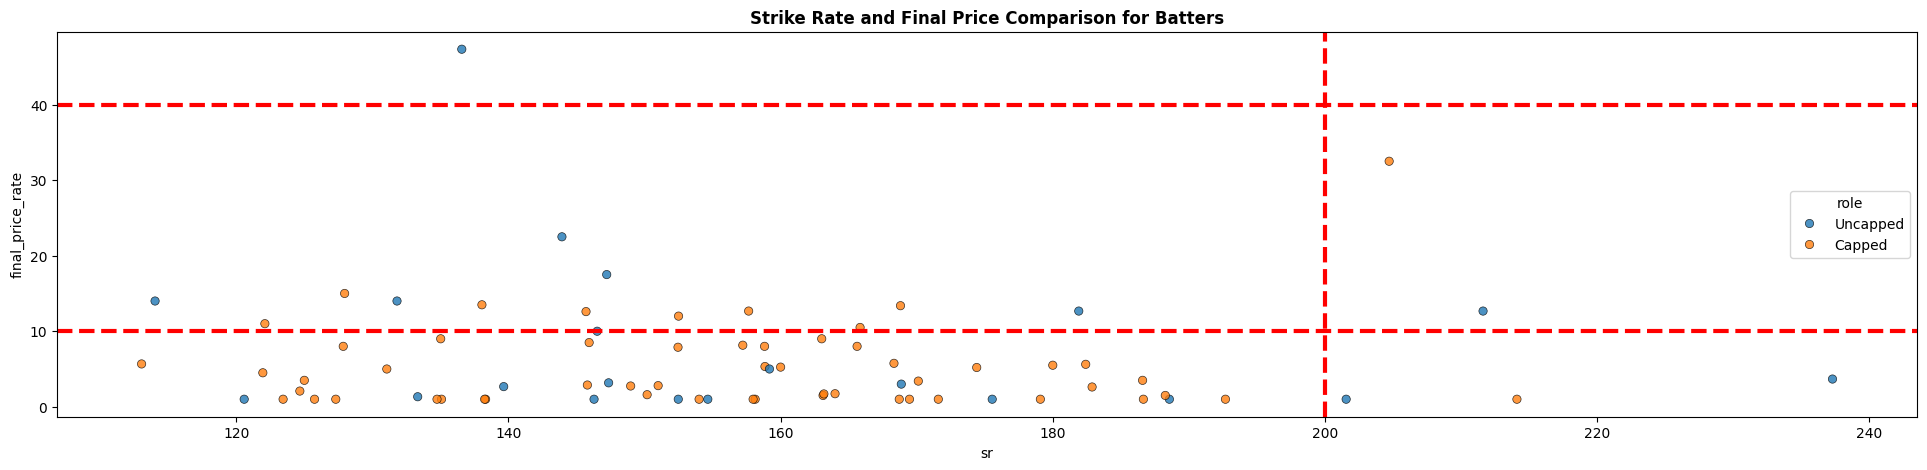

In [20]:
plt.figure(figsize=(24,5))
sns.scatterplot(x='sr',
                y='final_price_rate',
                data=only_batters,
                hue='role',
                alpha=0.8,
                edgecolor='black')
plt.axvline(200,color='red',linestyle='--',linewidth=3)
plt.axhline(40,color='red',linestyle='--',linewidth=3)
plt.axhline(10,color='red',linestyle='--',linewidth=3)
plt.title("Strike Rate and Final Price Comparison for Batters",weight='bold')
plt.show()

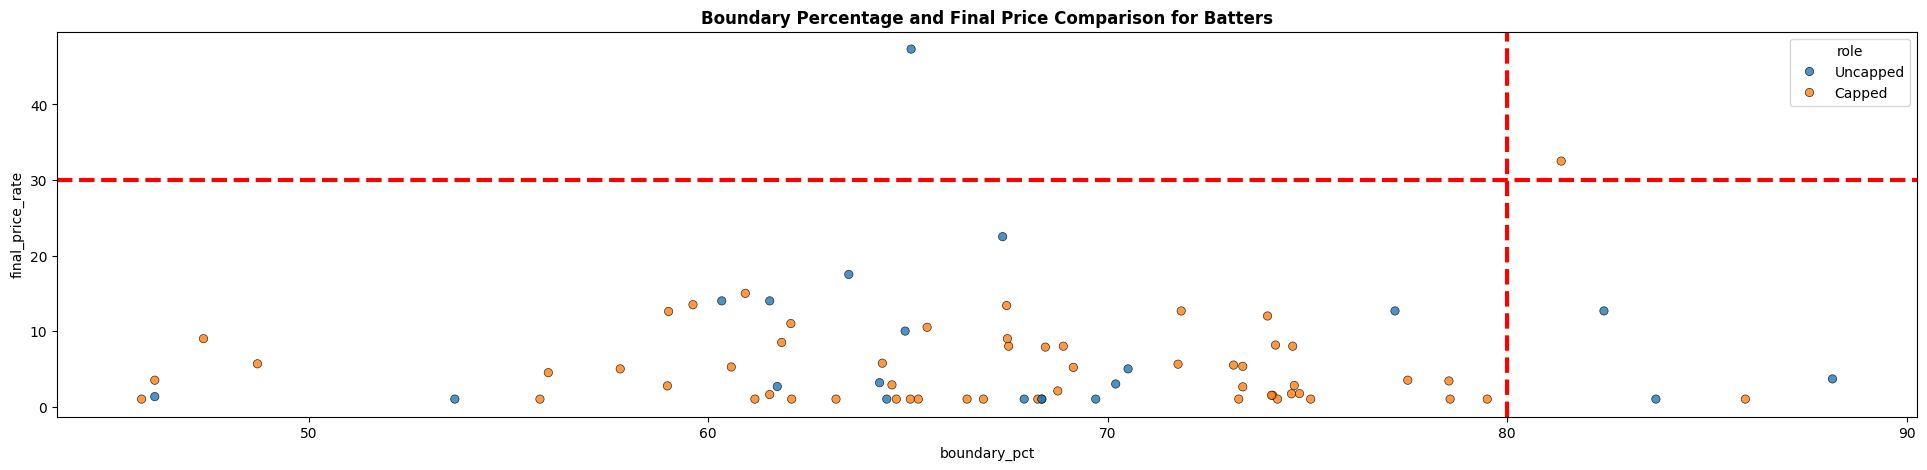

In [21]:
plt.figure(figsize=(24,5))
sns.scatterplot(x='boundary_pct',
                y='final_price_rate',
                data=only_batters,
                hue='role',
                alpha=0.8,
                edgecolor='black')
plt.axhline(30,color='red',linestyle='--',linewidth=3)
plt.axvline(80,color='red',linestyle='--',linewidth=3)
plt.title("Boundary Percentage and Final Price Comparison for Batters",weight='bold')
plt.show()

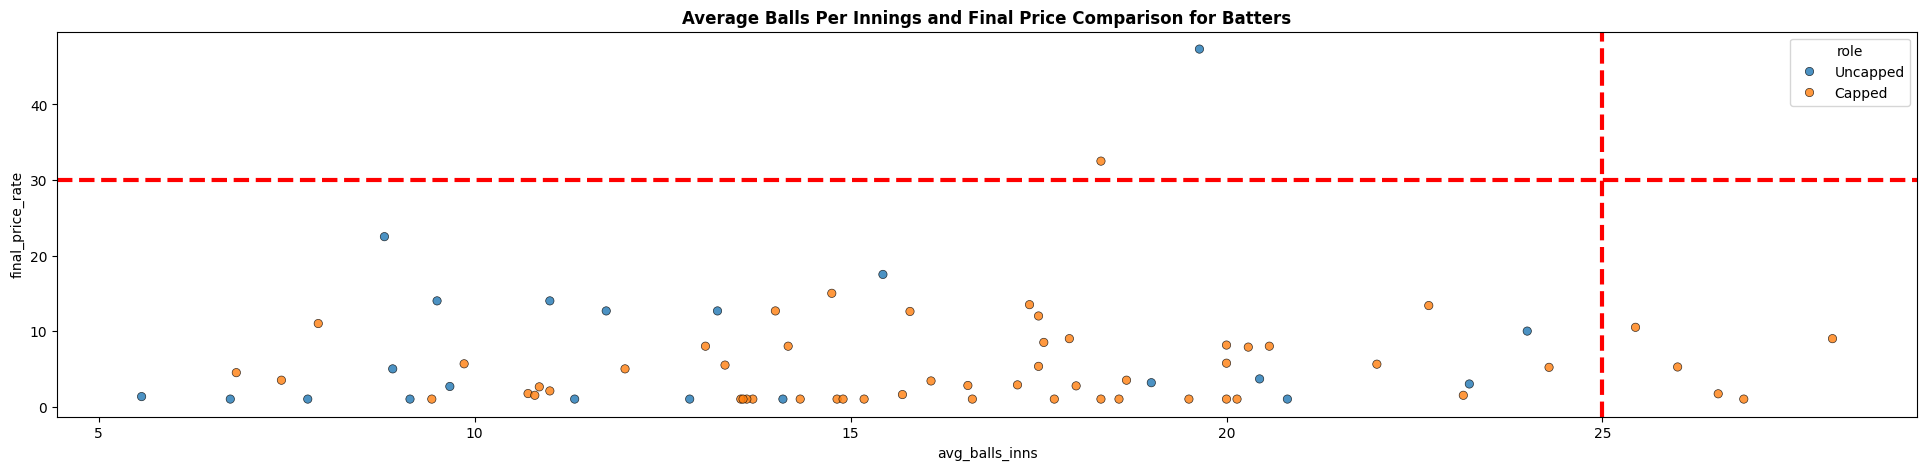

In [22]:
plt.figure(figsize=(24,5))
sns.scatterplot(x='avg_balls_inns',
                y='final_price_rate',
                data=only_batters,
                hue='role',
                alpha=0.8,
                edgecolor='black')
plt.axhline(30,color='red',linestyle='--',linewidth=3)
plt.axvline(25,color='red',linestyle='--',linewidth=3)
plt.title("Average Balls Per Innings and Final Price Comparison for Batters",weight='bold')
plt.show()

**BOWLERS**

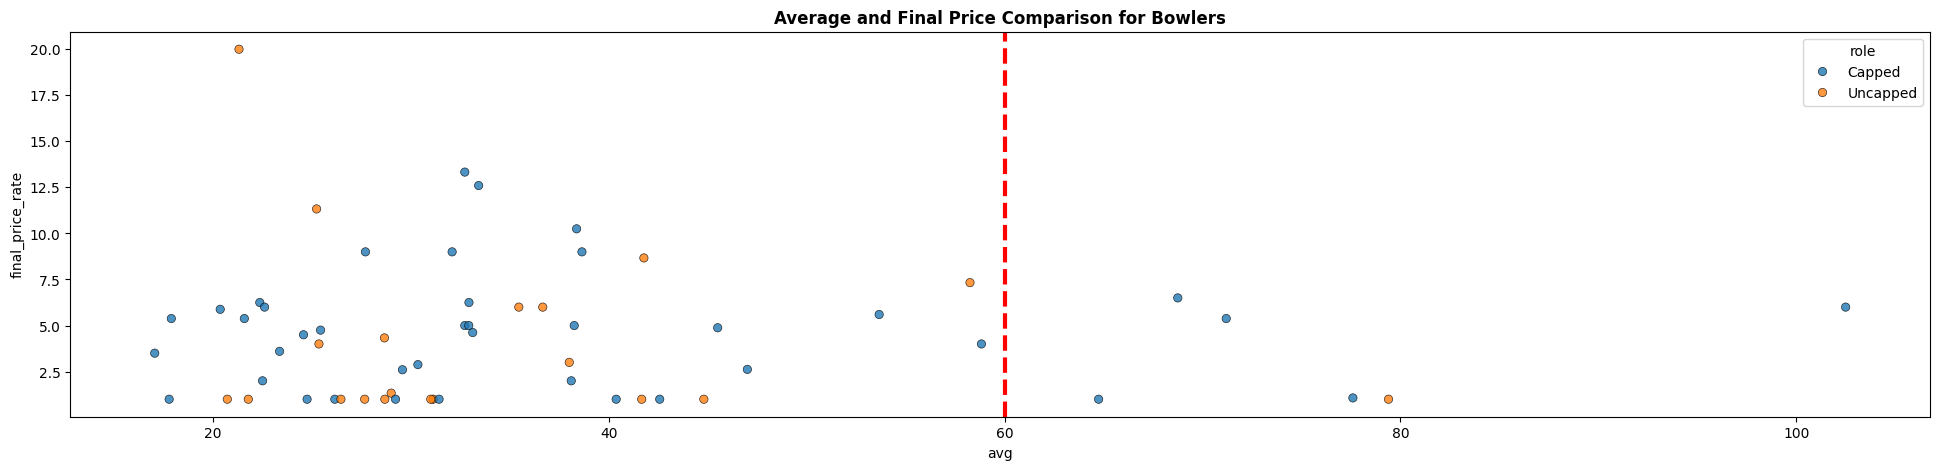

In [23]:
plt.figure(figsize=(24,5))
sns.scatterplot(x='avg',
                y='final_price_rate',
                data=only_bowlers,
                hue='role',
                alpha=0.8,
                edgecolor='black')
plt.axvline(60,color='red',linestyle='--',linewidth=3)
plt.title("Average and Final Price Comparison for Bowlers",weight='bold')
plt.show()

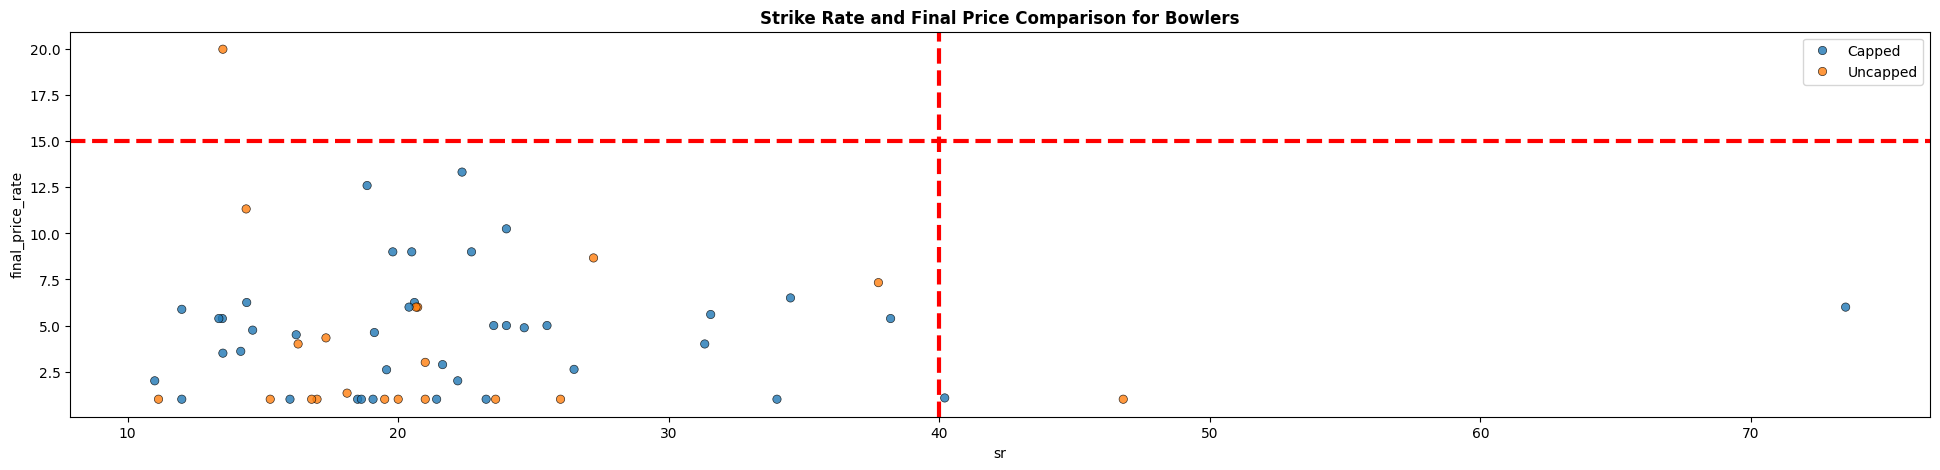

In [24]:
plt.figure(figsize=(24,5))
sns.scatterplot(x='sr',
                y='final_price_rate',
                data=only_bowlers,
                hue='role',
                alpha=0.8,
                edgecolor='black')
plt.axhline(15,color='red',linestyle='--',linewidth=3)
plt.axvline(40,color='red',linestyle='--',linewidth=3)
plt.title("Strike Rate and Final Price Comparison for Bowlers",weight='bold')
plt.legend()
plt.show()

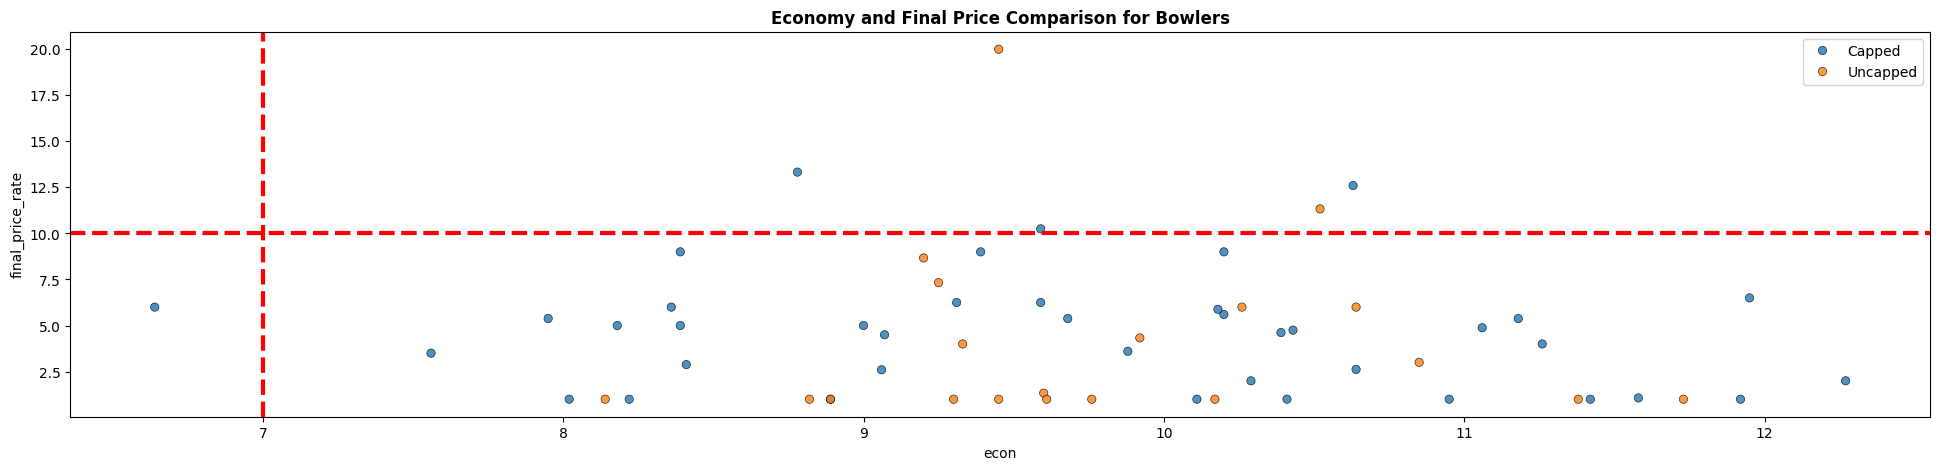

In [25]:
plt.figure(figsize=(24,5))
sns.scatterplot(x='econ',
                y='final_price_rate',
                data=only_bowlers,
                hue='role',
                alpha=0.8,
                edgecolor='black')
plt.axhline(10,color='red',linestyle='--',linewidth=3)
plt.axvline(7,color='red',linestyle='--',linewidth=3)
plt.title("Economy and Final Price Comparison for Bowlers",weight='bold')
plt.legend()
plt.show()

### 3.3 Correlation Check

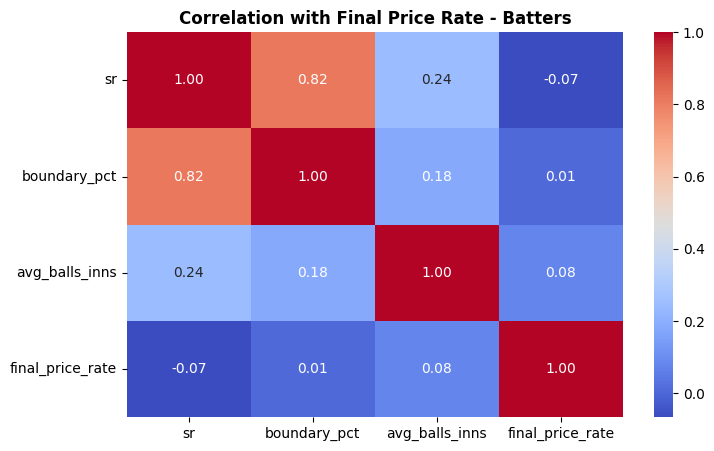

In [26]:
batters_corr = only_batters[['sr','boundary_pct','avg_balls_inns','final_price_rate']].corr()

plt.figure(figsize=(8,5))
sns.heatmap(batters_corr,annot=True,cmap='coolwarm',fmt='.2f')
plt.title("Correlation with Final Price Rate - Batters",weight='bold')
plt.show()

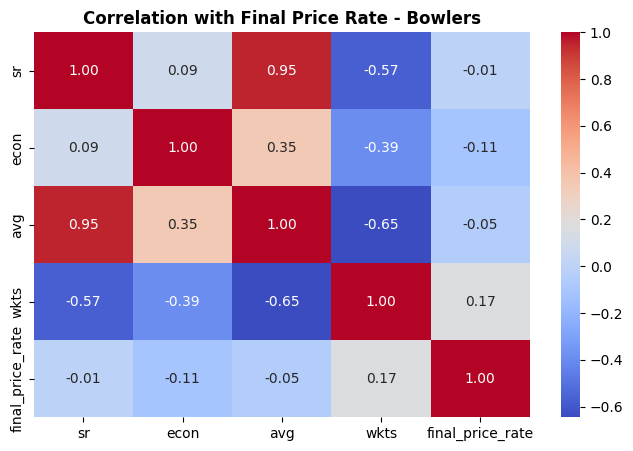

In [27]:
bowlers_corr = only_bowlers[['sr','econ','avg','wkts','final_price_rate']].corr()

plt.figure(figsize=(8,5))
sns.heatmap(bowlers_corr,annot=True,cmap='coolwarm',fmt='.2f')
plt.title("Correlation with Final Price Rate - Bowlers",weight='bold')
plt.show()

correlation with `final_price_rate` decides the weight given to each stat below, instead of picking weights by feel

## 4.Justification

### 4.1 Batters

In [28]:
batters_scaled = only_batters[['player','sr','boundary_pct','avg_balls_inns','role','final_price_rate']].copy()

scaler = MinMaxScaler()
batters_scaled[['sr','boundary_pct','avg_balls_inns']] = scaler.fit_transform(batters_scaled[['sr','boundary_pct','avg_balls_inns']])

In [29]:
batters_scaled['score_val'] = batters_scaled['sr']*4 + batters_scaled['boundary_pct']*4 + batters_scaled['avg_balls_inns']*2

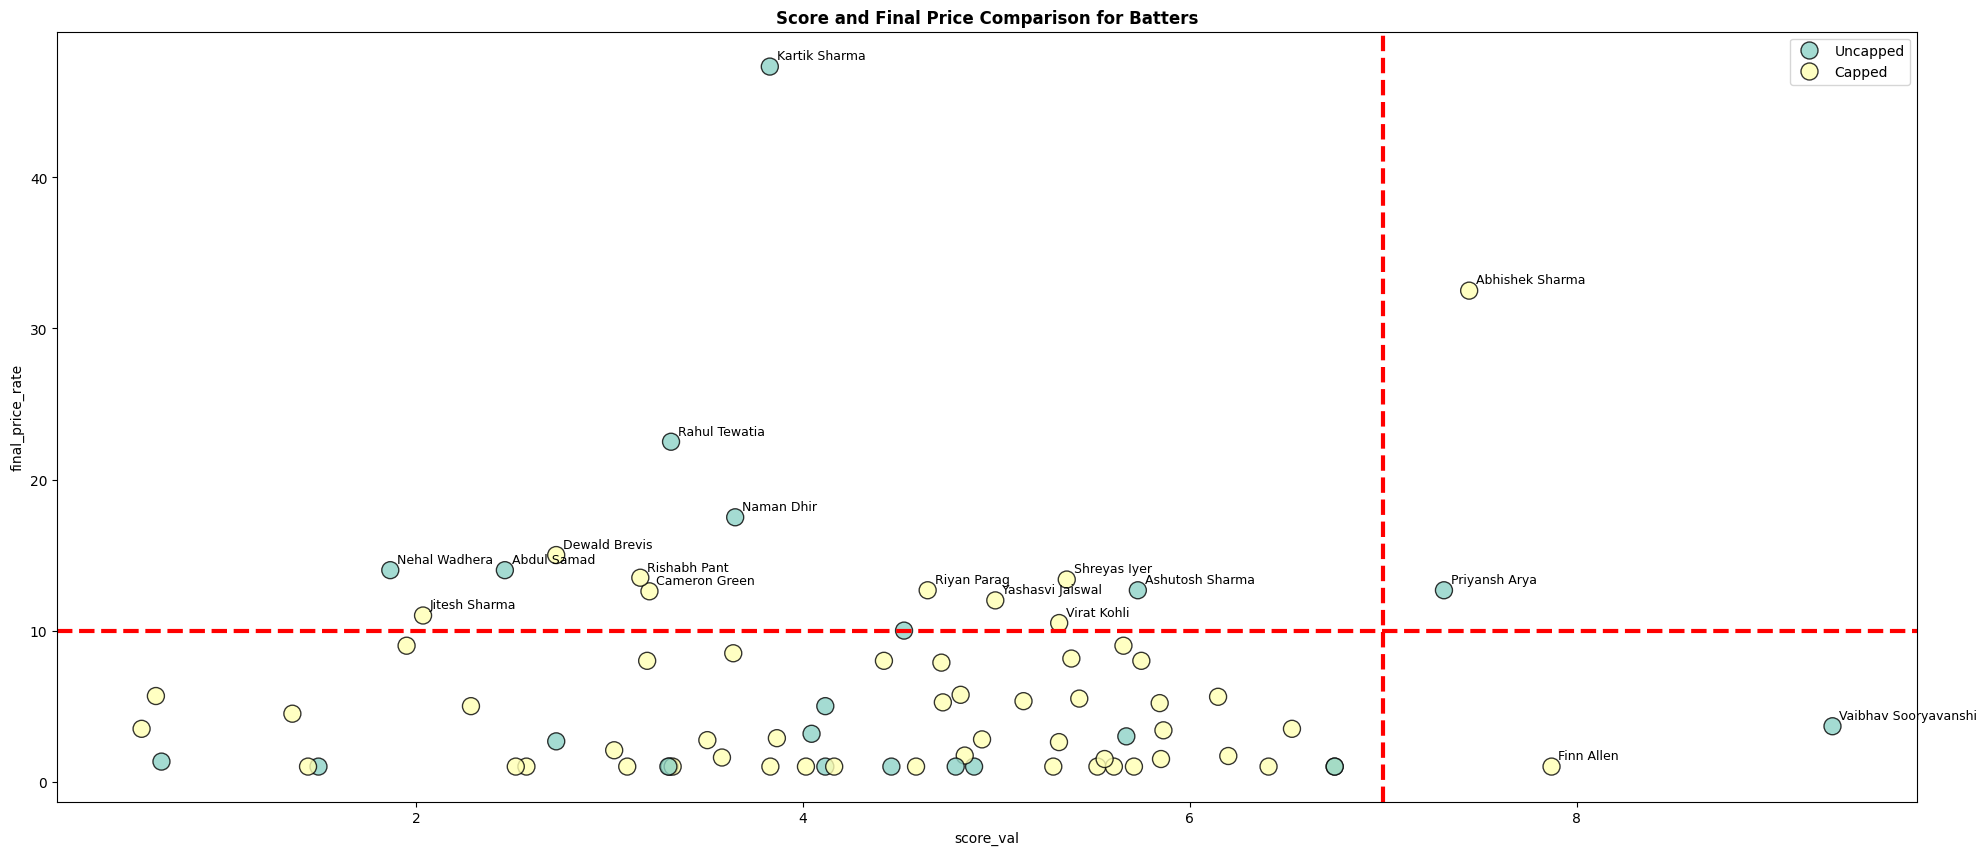

In [30]:
plt.figure(figsize=(24,10))
sns.scatterplot(x='score_val', y='final_price_rate', data=batters_scaled,
                hue='role', alpha=0.8, edgecolor='black',s=150,palette='Set3')

plt.axhline(10, color='red', linestyle='--', linewidth=3)
plt.axvline(7, color='red', linestyle='--', linewidth=3)

outliers = batters_scaled[(batters_scaled['final_price_rate'] > 10) | (batters_scaled['score_val'] > 7)]
for _, row in outliers.iterrows():
    plt.annotate(row['player'], (row['score_val'], row['final_price_rate']),
                 xytext=(5,5), textcoords='offset points', fontsize=9)

plt.title("Score and Final Price Comparison for Batters", weight='bold')
plt.legend()
plt.show()

### 4.2 Bowlers

In [31]:
bowlers_scaled = only_bowlers[['player','sr','econ','avg','wkts','role','final_price_rate']].copy()

scaler = MinMaxScaler()
bowlers_scaled[['sr','econ','avg','wkts']] = scaler.fit_transform(bowlers_scaled[['sr','econ','avg','wkts']])

In [32]:
bowlers_scaled['score_val'] = (1-bowlers_scaled['sr'])*3 + (1-bowlers_scaled['econ'])*3 + (1-bowlers_scaled['avg'])*2 + bowlers_scaled['wkts']*2

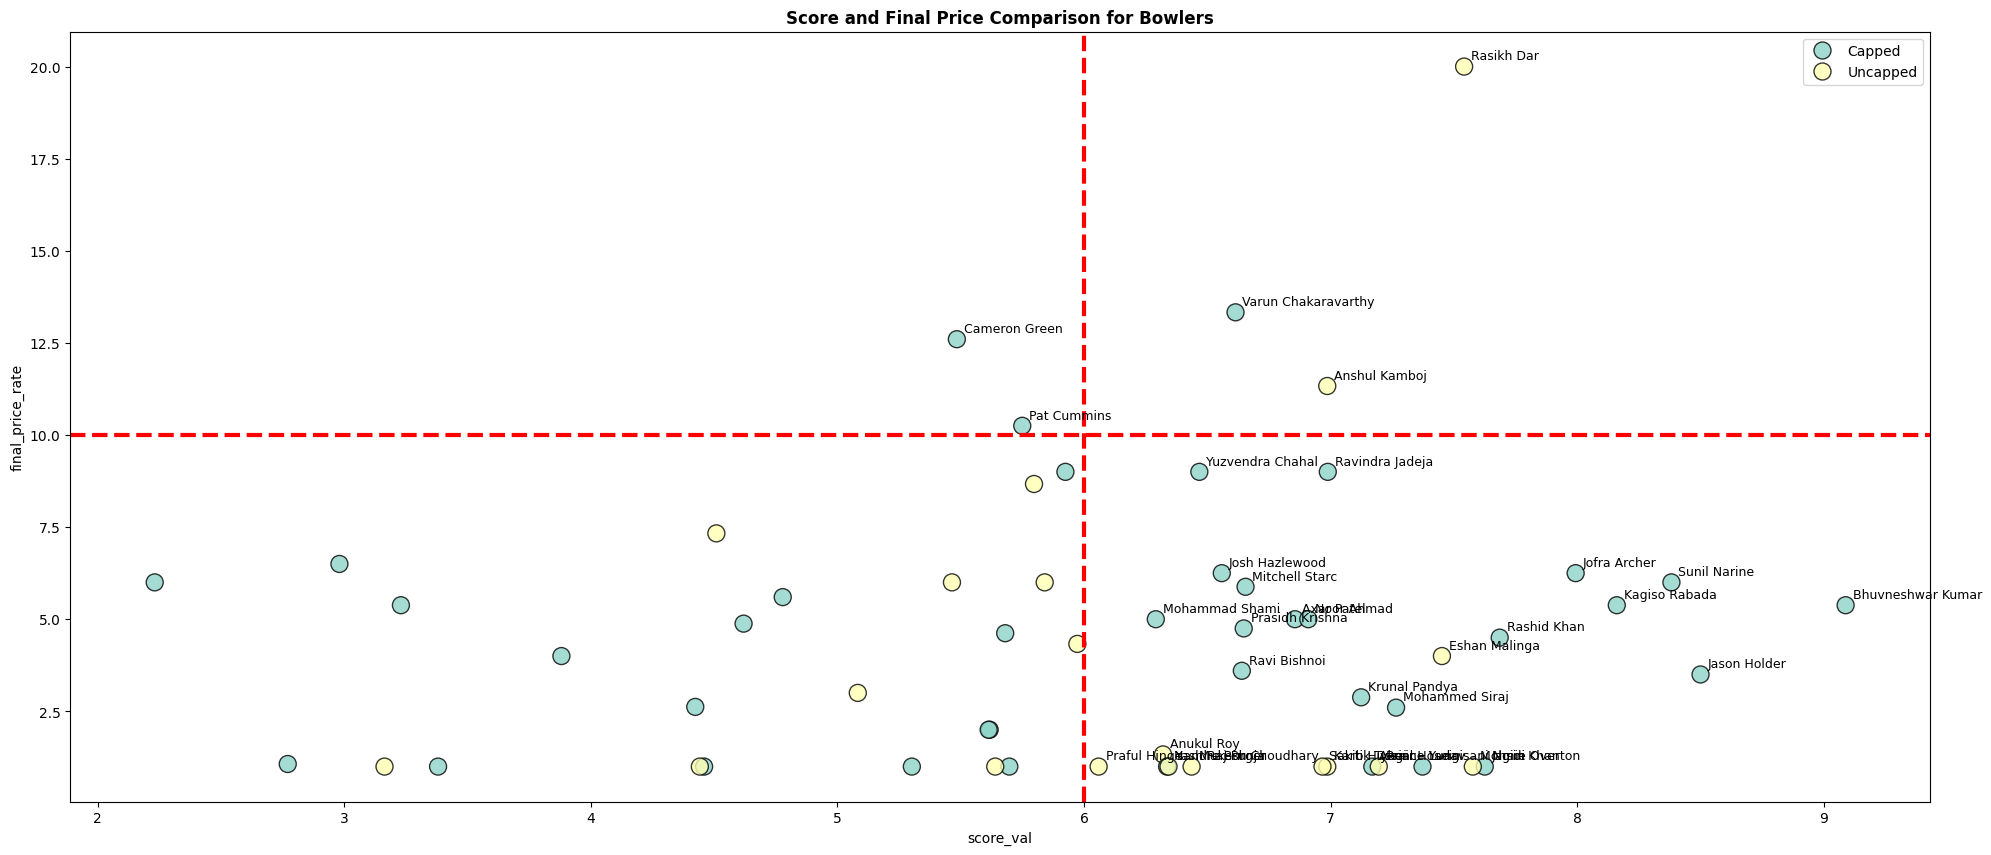

In [33]:
plt.figure(figsize=(24,10))
sns.scatterplot(x='score_val', y='final_price_rate', data=bowlers_scaled,
                hue='role', alpha=0.8, edgecolor='black', s=150, palette='Set3')

plt.axhline(10, color='red', linestyle='--', linewidth=3)
plt.axvline(6, color='red', linestyle='--', linewidth=3)

outliers = bowlers_scaled[(bowlers_scaled['final_price_rate'] > 10) | (bowlers_scaled['score_val'] > 6)]
for _, row in outliers.iterrows():
    plt.annotate(row['player'], (row['score_val'], row['final_price_rate']),
                 xytext=(5,5), textcoords='offset points', fontsize=9)

plt.title("Score and Final Price Comparison for Bowlers", weight='bold')
plt.legend()
plt.show()

---
---
***Final Findings:***

```Batters with high strike rate and boundary percentage justify higher price rates```

```Bowlers with low average, low economy and high wickets justify higher price rates```

---
---